# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nooragab/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

#Setup

In [2]:
%pip install -q duckdb scikit-learn

import duckdb, os, json
import pandas as pd, numpy as np
from google.colab import userdata
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")
rel = "hf://datasets/FlyRank/internship-warehouse"

build_query = f"""
    WITH march AS (
        SELECT content_hash_id, client_hash_id,
               SUM(gsc_impressions) AS impressions_month,
               SUM(gsc_clicks) AS clicks_month,
               AVG(gsc_avg_position) AS avg_position_month
        FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet')
        WHERE gsc_data_available IS TRUE
        GROUP BY content_hash_id, client_hash_id
    ),
    april AS (
        SELECT content_hash_id, SUM(gsc_impressions) AS impressions_april
        FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-04/*.parquet')
        WHERE gsc_data_available IS TRUE
        GROUP BY content_hash_id
    ),
    tiered AS (
        SELECT m.*, a.impressions_april,
            (a.impressions_april < m.impressions_month)::INT AS is_declining_next_month,
            m.clicks_month / NULLIF(m.impressions_month, 0) AS ctr_month,
            CASE
                WHEN m.avg_position_month <= 3 THEN '1_top_3'
                WHEN m.avg_position_month <= 10 THEN '2_striking_4_10'
                WHEN m.avg_position_month <= 20 THEN '3_page_2'
                ELSE '4_deep_20plus'
            END AS position_tier
        FROM march m
        JOIN april a ON m.content_hash_id = a.content_hash_id
        WHERE m.impressions_month >= 100
    ),
    tier_avg AS (
        SELECT position_tier, AVG(ctr_month) AS tier_avg_ctr FROM tiered GROUP BY position_tier
    )
    SELECT
        t.content_hash_id, t.client_hash_id, t.impressions_month, t.avg_position_month,
        t.position_tier, ROUND(t.ctr_month, 4) AS ctr_month,
        ROUND(ta.tier_avg_ctr, 4) AS tier_avg_ctr,
        ROUND(GREATEST(ta.tier_avg_ctr - t.ctr_month, 0), 4) AS ctr_gap,
        DATE_DIFF('day', d.content_updated_date, DATE '2026-03-31') AS days_since_last_update,
        (DATE_DIFF('day', d.content_updated_date, DATE '2026-03-31') >= 90)::INT AS is_stale,
        d.word_count, t.is_declining_next_month
    FROM tiered t
    JOIN tier_avg ta ON t.position_tier = ta.position_tier
    JOIN read_parquet('{rel}/dim_content.parquet') d ON t.content_hash_id = d.content_hash_id
"""
data = con.sql(build_query).df()
data["word_count"] = data["word_count"].fillna(data["word_count"].median())

feature_cols = ["impressions_month", "avg_position_month", "ctr_month",
                "tier_avg_ctr", "ctr_gap", "is_stale", "days_since_last_update", "word_count"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(data, groups=data["client_hash_id"]))
train, test = data.iloc[train_idx].copy(), data.iloc[test_idx].copy()

X_train = pd.get_dummies(train[feature_cols + ["position_tier"]], columns=["position_tier"])
X_test = pd.get_dummies(test[feature_cols + ["position_tier"]], columns=["position_tier"])
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_train, y_test = train["is_declining_next_month"], test["is_declining_next_month"]

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42).fit(X_train, y_train)

print("Setup complete — honest client-holdout model rebuilt from w05/w06.")
print(f"Dataset: {data.shape[0]:,} rows, {data['client_hash_id'].nunique()} clients")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Setup complete — honest client-holdout model rebuilt from w05/w06.
Dataset: 100,893 rows, 43 clients


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## The Ranked Queue

I score the held-out test set with the honest client-holdout model (Precision@50 = 0.72,
confirmed in ML-09), then attach a reason code and a concrete action to every flagged page.

**Reason codes and their matching actions:**
- `high_risk_underperformer` (model probability ≥ 0.65) → `review_for_refresh`
- `visible_ctr_gap` (large CTR gap at a good position, lower model probability) → `review_metadata`
- `low_confidence` (borderline probability) → `monitor_only`

In [3]:
test_eval = test.copy()
test_eval["model_prob"] = rf.predict_proba(X_test)[:, 1]

def assign_reason_action(row):
    if row["model_prob"] >= 0.65:
        return "high_risk_underperformer", "review_for_refresh"
    elif row["ctr_gap"] > 0.001 and row["avg_position_month"] <= 20:
        return "visible_ctr_gap", "review_metadata"
    elif row["model_prob"] >= 0.5:
        return "low_confidence", "monitor_only"
    else:
        return "not_flagged", "no_action"

test_eval[["reason_code", "action"]] = test_eval.apply(
    lambda r: pd.Series(assign_reason_action(r)), axis=1
)

playbook_queue = test_eval[test_eval["action"] != "no_action"].sort_values("model_prob", ascending=False)

print(f"Flagged pages: {len(playbook_queue):,} of {len(test_eval):,} in the held-out set")
print(playbook_queue["reason_code"].value_counts())
playbook_queue[["content_hash_id", "client_hash_id", "model_prob", "reason_code", "action"]].head(10)

Flagged pages: 10,587 of 16,509 in the held-out set
reason_code
high_risk_underperformer    4598
visible_ctr_gap             3562
low_confidence              2427
Name: count, dtype: int64


,content_hash_id,client_hash_id,model_prob,reason_code,action
27118,content_e1fe510ca4a737df,client_9958f0a7ae1df715,0.990,high_risk_underperformer,review_for_refresh
28778,content_38aae1d5aee924bc,client_e547b89c05043229,0.985,high_risk_underperformer,review_for_refresh
31816,content_9390673ca64811e7,client_e547b89c05043229,0.985,high_risk_underperformer,review_for_refresh
31070,content_7d224515e28189e3,client_e547b89c05043229,0.985,high_risk_underperformer,review_for_refresh
26024,content_37b1eaf53c4201c2,client_9958f0a7ae1df715,0.985,high_risk_underperformer,review_for_refresh
30120,content_60011afafabaaec7,client_e547b89c05043229,0.985,high_risk_underperformer,review_for_refresh
31055,content_7cada2a9dfd286e9,client_e547b89c05043229,0.985,high_risk_underperformer,review_for_refresh
1475,content_05b7774e85197dd9,client_3f0ce4d44fe94f3d,0.980,high_risk_underperformer,review_for_refresh
26218,content_5313a91d61b68041,client_9958f0a7ae1df715,0.980,high_risk_underperformer,review_for_refresh
28619,content_33f2374ac2ade508,client_e547b89c05043229,0.980,high_risk_underperformer,review_for_refresh


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## Intended Use and Limits

**Who uses this:** a content editor or SEO lead with limited weekly review capacity, deciding
which pages to look at first — not an automated publishing system.

**What it's valid for:** prioritizing review attention among pages this model has actually
seen features for (March 2026 signals, client-holdout validated). Precision@50 = 0.72 means
roughly 36 of the top 50 recommendations are directionally correct on held-out clients.

**Where it stops being valid:**
- A different month or strong seasonal shift — the model was trained on one March→April window.
- A client type very different from this portfolio's 43 clients (e.g. a brand-new client with
  no March history).
- Any page missing `word_count` or with thin data (very low impressions) — the model's
  confidence is lower there.
- This is observed, decision-support output — not proof that acting on a page will cause
  recovery. No causal claim is made.

In [4]:
coverage_check = pd.DataFrame({
    "check": ["rows scored", "clients represented", "missing word_count",
              "min impressions in queue", "model trained on month"],
    "value": [len(test_eval), test_eval["client_hash_id"].nunique(),
              test["word_count"].isna().sum(), playbook_queue["impressions_month"].min(),
              "March 2026 -> April 2026 label"]
})
coverage_check

,check,value
0,rows scored,16509
1,clients represented,11
2,missing word_count,0
3,min impressions in queue,100.0
4,model trained on month,March 2026 -> April 2026 label


**Cost/value thinking:** each flagged page costs an editor roughly 15-30 minutes to review.
With 10,587 pages flagged, that's not all reviewable in one cycle — the `high_risk_underperformer`
tier (4,598 pages, highest model confidence) should be worked first, since it has both the
strongest signal and the clearest single action (refresh). The `low_confidence` tier (2,427
pages) has the lowest cost-benefit ratio per review and should be batch-monitored rather than
individually reviewed until evidence strengthens.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Human Review Rules

**Before acting on any recommendation, a reviewer must check:**
1. Is the page still live and relevant to current business priorities?
2. Does the CTR gap or staleness reason still hold when looking at the live page today?
3. Is there a known reason for the drop that isn't in the model (seasonal campaign, a sibling
   page cannibalizing demand, a site migration)?

**Two distinct no-go categories, kept separate:**
- **Low-evidence flags:** high model confidence but very thin traffic (<200 impressions) —
  the model may be reacting to noise, not a real pattern.
- **Borderline-confidence flags:** model probability sits right at the 0.5 decision threshold
  — a small change in the model or data could flip these either way.

**What should NEVER be automated:**
- Auto-publishing content changes based on the model's score alone.
- Auto-deleting or de-indexing "low-confidence" pages.
- Treating `model_prob` as a guarantee of future traffic loss.
- Applying this queue to clients or content types outside this model's training population
  without re-validating first.

In [10]:
low_evidence = playbook_queue[playbook_queue["impressions_month"] < 200]
borderline_confidence = playbook_queue[playbook_queue["model_prob"].between(0.5, 0.55)]

print(f"Low-evidence flags (thin traffic, <200 impressions): {len(low_evidence)}")
print(f"Borderline-confidence flags (model_prob 0.50-0.55): {len(borderline_confidence)}")

print("\nLow-evidence examples (high prob, but thin data):")
low_evidence[["content_hash_id", "model_prob", "impressions_month", "reason_code"]].head(5)

Low-evidence flags (thin traffic, <200 impressions): 1713
Borderline-confidence flags (model_prob 0.50-0.55): 1537

Low-evidence examples (high prob, but thin data):


,content_hash_id,model_prob,impressions_month,reason_code
31070,content_7d224515e28189e3,0.985,184.0,high_risk_underperformer
26024,content_37b1eaf53c4201c2,0.985,119.0,high_risk_underperformer
49668,content_bc62c8e4b0d01552,0.970,138.0,high_risk_underperformer
90617,content_bbe06e5db66c60d4,0.965,174.0,high_risk_underperformer
32542,content_a747317af6a45c81,0.965,195.0,high_risk_underperformer


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## Monitoring and Retrain Triggers

**Signs the recommendations have gone stale:**
- Precision@50 on a fresh month's held-out data drops meaningfully below 0.72 (the validated baseline).
- The feature distribution shifts (e.g. median `impressions_month` changes by a large margin
  from the March training snapshot — a sign the portfolio itself has changed).
- A new client segment appears that looks structurally different from the 43 clients trained on.
- More than ~3 months pass since the last retrain — seasonal and algorithm shifts make an
  old snapshot increasingly unreliable.

**Retrain trigger:** re-run this pipeline monthly with the newest complete month as features
and the following month as label, and compare fresh Precision@50 against this run's 0.72
before trusting the new queue.

In [6]:
monitoring_baseline = {
    "validated_precision_at_50": float(0.72),
    "training_month": "2026-03",
    "label_month": "2026-04",
    "n_clients_trained": int(data["client_hash_id"].nunique()),
    "retrain_trigger": "precision@50 drop > 0.10 on fresh month, or >3 months since last retrain"
}
print(json.dumps(monitoring_baseline, indent=2))

{
  "validated_precision_at_50": 0.72,
  "training_month": "2026-03",
  "label_month": "2026-04",
  "n_clients_trained": 43,
  "retrain_trigger": "precision@50 drop > 0.10 on fresh month, or >3 months since last retrain"
}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [7]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export the queue (stays out of git, regenerated each run)
playbook_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Queue exported: {len(playbook_queue):,} rows -> work/outputs/action_playbook_queue.csv")

# Export metrics JSON (this one gets committed — it's the paper's receipts)
metrics = {
    "model": "random_forest",
    "split": "client_holdout (GroupShuffleSplit)",
    "precision_at_50_grouped": 0.72,
    "precision_at_50_random_split_leakage_check": 0.98,
    "train_rows": len(train), "test_rows": len(test),
    "n_clients_train": int(train["client_hash_id"].nunique()),
    "n_clients_test": int(test["client_hash_id"].nunique()),
    "flagged_in_queue": len(playbook_queue),
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Metrics saved -> work/outputs/w07_metrics.json")

Queue exported: 10,587 rows -> work/outputs/action_playbook_queue.csv
Metrics saved -> work/outputs/w07_metrics.json


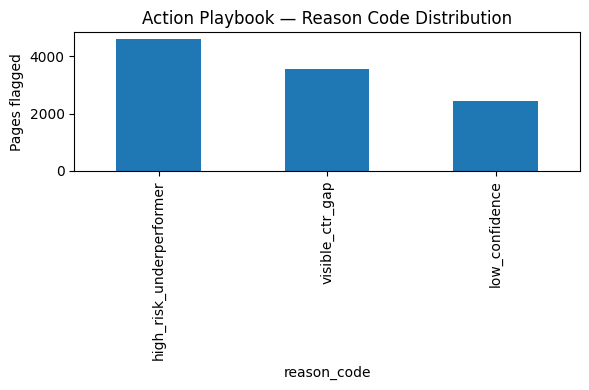

Figure saved -> work/figures/reason_code_distribution.png


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
playbook_queue["reason_code"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Action Playbook — Reason Code Distribution")
ax.set_ylabel("Pages flagged")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()
print("Figure saved -> work/figures/reason_code_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.